# Task 1

| Name                           | Abbreviation | Equation                                                                                      |
|--------------------------------|--------------|-----------------------------------------------------------------------------------------------|
| Probability density function   | pdf          | $$ p(x) $$                                                                                    |
| Normalization                  | norm         | $$ E(1) = \int \frac{{x - \text{min}(x)}}{{\text{max}(x) - \text{min}(x)}} \, dx $$           |
| Cumulative density function    | cdf          | $$ C(x) = \int_{-\infty}^{x} p(t) \, dt $$                                                    |
| Mean                           | μ            | $$ E(x) = \frac{1}{N} \sum_{i=1}^{N} x_i $$                                                     |
| Variance                       | Var(x)       | $$ \text{Var}(x) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^2 $$                             |
| Skewness                       | Skew(x)      | $$ \text{Skew}(x) = \frac{{E((x - μ)^3)}}{{\sigma^3}} $$                                       |
| Kurtosis                       | Kurt(x)      | $$ \text{Kurt}(x) = \frac{{E((x - μ)^4)}}{{\sigma^4}} - 3 $$                                   |
| General expectation value     | E(g(x))      | $$ E(g(x)) = \int_{\text{min}(x)}^{\text{max}(x)} g(x) \, p(x) \, dx $$                        |
| Inverse cumulative density    | icdf         | $$ x = C^{-1}(p) $$                                                                           |
| Median                         | Median       | $$ \text{median} = C^{-1}(0.5) $$                                                              |
| Percentile function           | Percentile   | $$ p = C^{-1}(x) $$                                                                           |


# Task 3 Numerical integration

In [1]:
import numpy as np

def numerical_integration(func, a, b, N):
    x_values = np.linspace(a, b, N)
    
    delta_x = (b - a) / N
    
    integral_sum = 0
    
    for x in x_values:
        height = func(x)
        
        integral_sum += height * delta_x
    
    return integral_sum

integral_1 = numerical_integration(lambda x: x, 0, 1, 1000)
integral_2 = numerical_integration(lambda x: x**2, 0, 1, 1000)

print("Integral of x from 0 to 1:", integral_1)
print("Integral of x^2 from 0 to 1:", integral_2)


Integral of x from 0 to 1: 0.5
Integral of x^2 from 0 to 1: 0.33350016683350003


# Task 4 Hypercube and Hypersphere

In [2]:
import numpy as np
from scipy.special import gamma
import matplotlib.pyplot as plt

volumes = []

def estimate_hypersphere_volume(dimensions, num_points=10**6):
    volume_ratios = []
    for n in range(1, dimensions + 1):
        # Step 1: Generate random points in the hypercube [-1, 1]^n
        points = np.random.uniform(-1, 1, size=(num_points, n))
        
        # Step 2: Check how many points lie within the hypersphere of radius 1
        within_sphere = np.linalg.norm(points, axis=1) <= 1
        points_in_sphere = np.sum(within_sphere)
        
        # Calculate the volume ratio
        volume_ratio = points_in_sphere / num_points
        volume_ratios.append(volume_ratio)
        
        volume = points_in_sphere / num_points * (2 ** n)  # Scale by hypercube volume
        volumes.append(volume)
    
    return volume_ratios, volumes

# Step 4: Perform the experiment for dimensions between 1 and 10
dimensions = 10
volume_ratios = estimate_hypersphere_volume(dimensions)

volume_ratios

([1.0,
  0.785561,
  0.523862,
  0.308556,
  0.164269,
  0.080537,
  0.037145,
  0.015839,
  0.006514,
  0.00248],
 [2.0,
  3.142244,
  4.190896,
  4.936896,
  5.256608,
  5.154368,
  4.75456,
  4.054784,
  3.335168,
  2.53952])

In [3]:
# Step 5: Calculate the volume of the hypersphere analytically
def analytical_hypersphere_volume(dimensions):
    return np.pi**(dimensions / 2) / gamma(dimensions / 2 + 1)

analytical_volumes = [analytical_hypersphere_volume(n) for n in range(1, dimensions + 1)]
analytical_volumes

[2.0,
 3.141592653589793,
 4.188790204786391,
 4.934802200544679,
 5.263789013914324,
 5.167712780049969,
 4.724765970331401,
 4.058712126416768,
 3.2985089027387064,
 2.550164039877345]

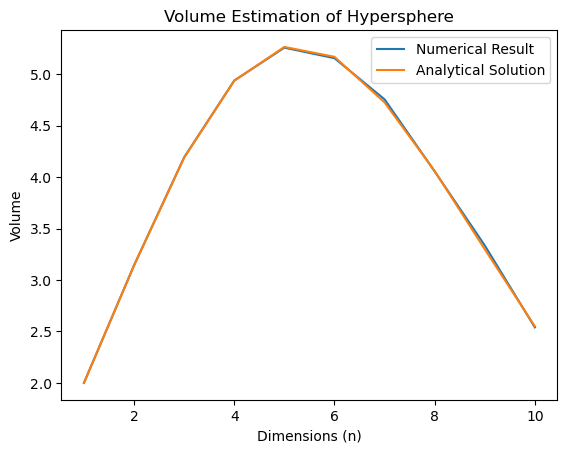

In [4]:
plt.plot(range(1, dimensions + 1), volumes, label='Numerical Result')
plt.plot(range(1, dimensions + 1), analytical_volumes, label='Analytical Solution')
plt.xlabel('Dimensions (n)')
plt.ylabel('Volume')
plt.title('Volume Estimation of Hypersphere')
plt.legend()
plt.show()